### Primer análisis de los datos 
#### 11/03/2026

In [102]:
# Importaciones necesarias y semilla
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from umap import UMAP

SEED = 777

In [68]:
# Cargamos los datos 
data = pd.read_excel(io='Dataset_01_Anonimizado.xlsx', decimal=',')

#### Primeros valores 

In [ ]:
data.head()

,ID,Variable de Salida,Variable 01,Variable 02,Variable 03,Variable 04,Variable 05,Variable 06,Variable 07,Variable 08,...,Variable 92,Variable 93,Variable 94,Variable 95,Variable 96,Variable 97,Variable 98,Variable 99,Variable 100,Variable 101
0,100001,OK,DERECHA,EVENT TYPE G,2.0,8.0,11.0,19.0,17.061905,25.300001,...,A,92.016667,5,5,BR,1,31,109.38,77,BR
1,100002,NOK,IZQUIERDA,EVENT TYPE G,3.0,8.0,10.0,5.5,17.010526,25.100000,...,A,92.250000,6,6,BR,1,28,83.22,76,BR
2,100003,NOK,DERECHA,EVENT TYPE G,2.0,6.0,12.0,3.5,16.980000,25.100000,...,A,92.283333,7,7,BR,1,31,124.05,77,BR
3,100004,NOK,IZQUIERDA,EVENT TYPE G,3.0,6.0,13.0,5.5,16.961905,25.200000,...,A,92.300000,8,8,BR,1,28,83.22,76,BR
4,100005,NOK,DERECHA,EVENT TYPE G,2.0,6.0,12.0,5.0,16.963636,25.200000,...,A,92.333333,9,9,BR,1,30,125.63,79,BR


#### Posibles duplicados o nulos 

In [ ]:
# Posibles duplicados
data.duplicated().sum()

np.int64(0)

In [ ]:
# Posibles nulos 
nulls = [(i, data[i].isnull().sum()) for i in data.columns if data[i].isnull().sum() > 0]
nulls

[]

#### Tipos de dato 

In [7]:
# Primer vistazo
data.dtypes

ID                      int64
Variable de Salida        str
Variable 01               str
Variable 02               str
Variable 03           float64
                       ...   
Variable 97             int64
Variable 98             int64
Variable 99           float64
Variable 100            int64
Variable 101              str
Length: 103, dtype: object

In [38]:
# Consultamos valores de las variables categóricas. 
different_types = [(i,data[i].unique()) for i in data.columns if data[i].dtypes not in ['int64', 'float64']]
for i in different_types: print(f'{i}\n')

('Variable de Salida', <StringArray>
['OK', 'NOK']
Length: 2, dtype: str)

('Variable 01', <StringArray>
['DERECHA', 'IZQUIERDA']
Length: 2, dtype: str)

('Variable 02', <StringArray>
['EVENT TYPE G']
Length: 1, dtype: str)

('Variable 91', <StringArray>
['A', 'N', 'B']
Length: 3, dtype: str)

('Variable 92', array(['A', 'N', 0, 'B'], dtype=object))

('Variable 96', <StringArray>
['BR', 'PR', 'CI', 'AZ']
Length: 4, dtype: str)

('Variable 101', <StringArray>
['BR', 'PR', 'CI', 'AZ']
Length: 4, dtype: str)



In [ ]:
# TODO Preguntar a Andrés por la variable 92
# TODO Borrar Variable 02 porque no tiene ningún tipo de sentido

#### Variables categóricas

In [70]:
# Hacemos OneHot para graficar más tarde

#BORRAMOS POR AHORA LA VARIABLE 92 y la 02...
data_target = data['Variable de Salida'].apply(lambda x: 1 if x == 'OK' else 0)

data.drop(columns=['Variable 92', 'Variable 02', 'Variable de Salida'], inplace=True)

categorical_columns = [i for i in data.columns if data[i].dtypes not in ['int64', 'float64']]
# equivalente a one-hot en pandas (ya importado...)
data_encoded = pd.get_dummies(columns=categorical_columns, data=data)

print(f"Dimensiones antes del encoding: {data.shape}, después: {data_encoded.shape}")

Dimensiones antes del encoding: (1029, 100), después: (1029, 109)


#### Normalización - Estandarización

In [103]:
# Normalizamos los datos para PCA y UMAP
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_encoded)

#### Graficación (PCA y UMAP)

In [105]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(data_scaled)
print(f"Se captura {round(sum(pca.explained_variance_ratio_) * 100, 2)}% de la varianza")

Se captura 53.94% de la varianza


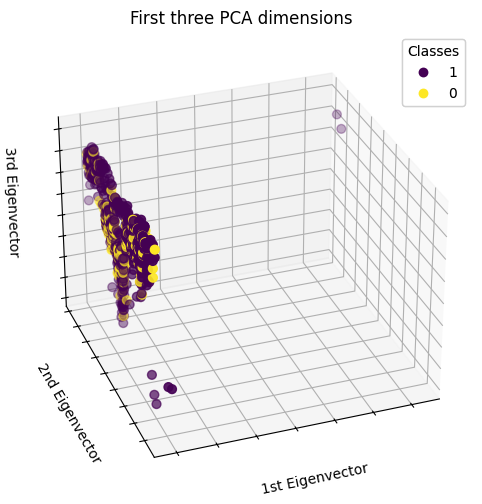

In [106]:
# Graficamos las 3 primeras componentes principales de PCA
fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d', elev=-150, azim=110)

scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2],
    c=data_target,
    s=40,
)

ax.set(
    title="First three PCA dimensions",
    xlabel="1st Eigenvector",
    ylabel="2nd Eigenvector",
    zlabel="3rd Eigenvector",
)
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])

# Add a legend
legend1 = ax.legend(
    scatter.legend_elements()[0],
    data_target.unique(),
    loc="upper right",
    title="Classes",
)
ax.add_artist(legend1)

plt.show()

In [128]:
# UMAP con ajuste de hiperparámetros (como un grid search pero a mano)
umap = UMAP(random_state=SEED, n_neighbors=4, min_dist=0.01, metric='correlation')
emb_umap = umap.fit_transform(data_scaled)

/home/mrtn/miniconda3/envs/pluto/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


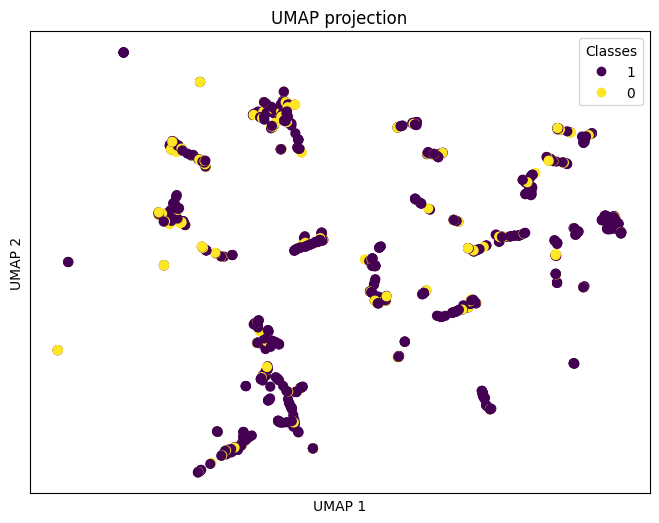

In [129]:
# Graficamos UMAP 
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    emb_umap[:, 0],
    emb_umap[:, 1],
    c=data_target,
    s=40,
)
plt.title("UMAP projection")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.xticks([])
plt.yticks([])
# Add a legend
legend1 = plt.legend(
    scatter.legend_elements()[0],
    data_target.unique(),
    loc="upper right",
    title="Classes",
)
plt.show()
